# Customer Churn Prediction

## Objective
Predict whether a customer is likely to churn using customer demographic,
service usage, contract, billing, and account information.

## Machine Learning Problem
Supervised Binary Classification

## Dataset
Telco Customer Churn Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [5]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [6]:
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [7]:
#at this point i have loaded the file here
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [8]:
#now i am gonna load the datasethere
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Dataset loaded succesfully")

Dataset loaded succesfully


In [9]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
print("no of row", df.shape[0])
print("no of columns", df.shape[1])

no of row 7043
no of columns 21


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [12]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df["customerID"].duplicated().sum()

np.int64(0)

In [15]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [16]:
df["Churn"].value_counts(normalize=True)*100

,proportion
Churn,
No,73.463013
Yes,26.536987


In [17]:
df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [18]:
categorical_columns = df.select_dtypes(include="object").columns
print(categorical_columns)

Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')


In [19]:
numerical_columns= df.select_dtypes(include=np.number).columns
print(numerical_columns)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')


In [ ]:
#now after all of this i need to create a summary so that i dont forget
print("Dataset Shape:", df.shape)
print("Duplicate Rows:", df.duplicated().sum())
print("Duplicate Customer IDs:", df["customerID"].duplicated().sum())

print("\nTarget Distribution:")
print(df["Churn"].value_counts())

print("\nCategorical Columns:", len(categorical_columns))
print("Numerical Columns:", len(numerical_columns))

Dataset Shape: (7043, 21)
Duplicate Rows: 0
Duplicate Customer IDs: 0

Target Distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Categorical Columns: 18
Numerical Columns: 3


In [20]:
df_clean = df.copy()

In [21]:
print("original shape ", df.shape)
print("working dataset shape", df_clean.shape)

original shape  (7043, 21)
working dataset shape (7043, 21)


In [22]:
df_clean["TotalCharges"].dtype

dtype('O')

In [23]:
(df_clean["TotalCharges"] == " ").sum()

np.int64(11)

In [24]:
df_clean["TotalCharges"] = pd.to_numeric(
    df_clean["TotalCharges"],
    errors="coerce"
)

In [25]:
print(df_clean["TotalCharges"].dtype)

float64


In [26]:
df_clean["TotalCharges"].isnull().sum()

np.int64(11)

In [27]:
df_clean[df_clean["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [28]:
df_clean["TotalCharges"] = df_clean["TotalCharges"].fillna(0)

In [29]:
df_clean["TotalCharges"].isnull().sum()

np.int64(0)

In [30]:
df_clean.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [31]:
print("Duplicate rows:", df_clean.duplicated().sum())

Duplicate rows: 0


In [32]:
print("Duplicate customer IDs:", df_clean["customerID"].duplicated().sum())

Duplicate customer IDs: 0


In [33]:
for col in df_clean.select_dtypes(include="object").columns:
    print("\n", col)
    print(df_clean[col].unique())


 customerID
['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']

 gender
['Female' 'Male']

 Partner
['Yes' 'No']

 Dependents
['No' 'Yes']

 PhoneService
['No' 'Yes']

 MultipleLines
['No phone service' 'No' 'Yes']

 InternetService
['DSL' 'Fiber optic' 'No']

 OnlineSecurity
['No' 'Yes' 'No internet service']

 OnlineBackup
['Yes' 'No' 'No internet service']

 DeviceProtection
['No' 'Yes' 'No internet service']

 TechSupport
['No' 'Yes' 'No internet service']

 StreamingTV
['No' 'Yes' 'No internet service']

 StreamingMovies
['No' 'Yes' 'No internet service']

 Contract
['Month-to-month' 'One year' 'Two year']

 PaperlessBilling
['Yes' 'No']

 PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

 Churn
['No' 'Yes']


In [34]:
df_clean[["tenure", "MonthlyCharges", "TotalCharges"]].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [35]:
print("Negative tenure:", (df_clean["tenure"] < 0).sum())
print("Negative MonthlyCharges:", (df_clean["MonthlyCharges"] < 0).sum())
print("Negative TotalCharges:", (df_clean["TotalCharges"] < 0).sum())

Negative tenure: 0
Negative MonthlyCharges: 0
Negative TotalCharges: 0


In [36]:
print("Final shape:", df_clean.shape)

print("\nData types:")
print(df_clean.dtypes)

print("\nMissing values:")
print(df_clean.isnull().sum().sum())

print("\nDuplicate rows:")
print(df_clean.duplicated().sum())

Final shape: (7043, 21)

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

Missing values:
0

Duplicate rows:
0


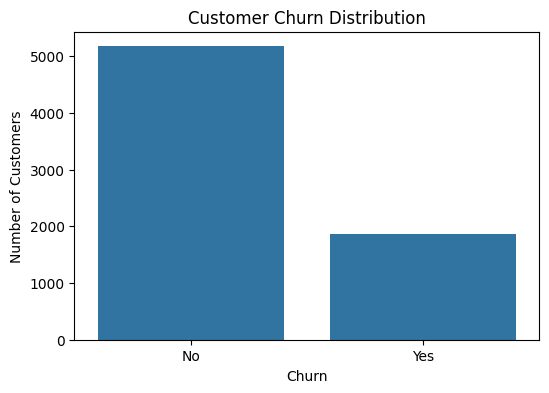

In [37]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df_clean, x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [38]:
churn_counts = df_clean["Churn"].value_counts()

churn_rate = (
    df_clean["Churn"]
    .value_counts(normalize=True)
    .mul(100)
)

print("Customer Count:")
print(churn_counts)

print("\nChurn Percentage:")
print(churn_rate)

Customer Count:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


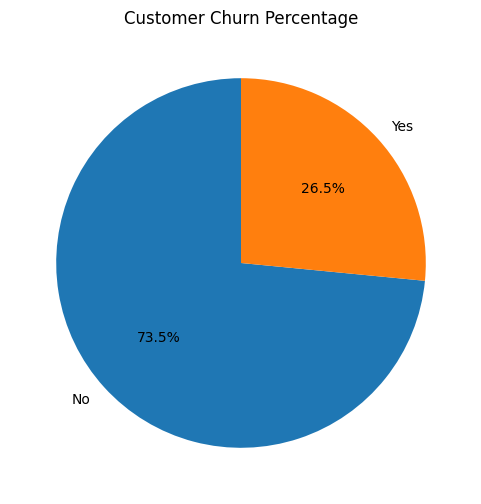

In [39]:
plt.figure(figsize=(6, 6))

df_clean["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Churn Percentage")
plt.ylabel("")

plt.show()

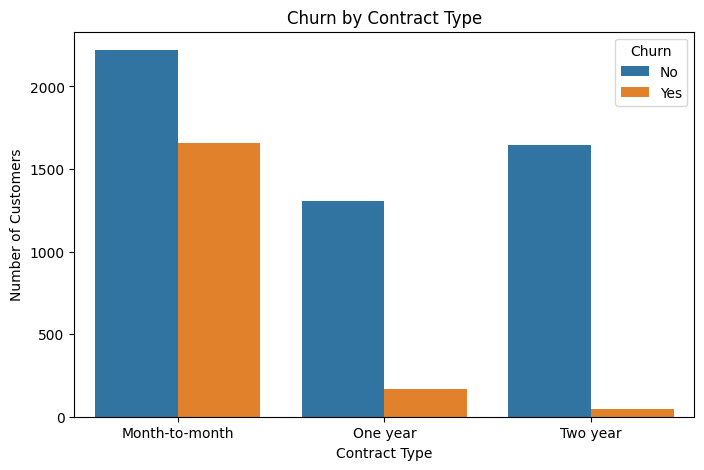

In [40]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="Contract",
    hue="Churn"
)

plt.title("Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

In [41]:
contract_churn = pd.crosstab(
    df_clean["Contract"],
    df_clean["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


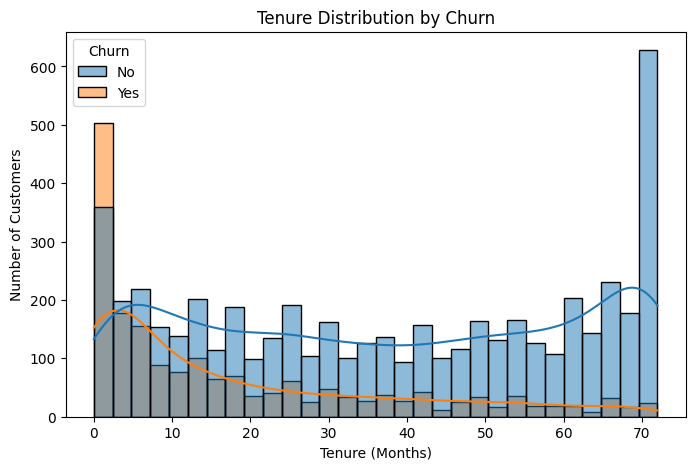

In [42]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_clean,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

In [43]:
df_clean["TenureGroup"] = pd.cut(
    df_clean["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12 Months", "13-24 Months", "25-48 Months", "49-72 Months"]
)

In [44]:
tenure_churn = pd.crosstab(
    df_clean["TenureGroup"],
    df_clean["Churn"],
    normalize="index"
) * 100

tenure_churn

Churn,No,Yes
TenureGroup,,
0-12 Months,52.561757,47.438243
13-24 Months,71.289062,28.710938
25-48 Months,79.611041,20.388959
49-72 Months,90.486824,9.513176


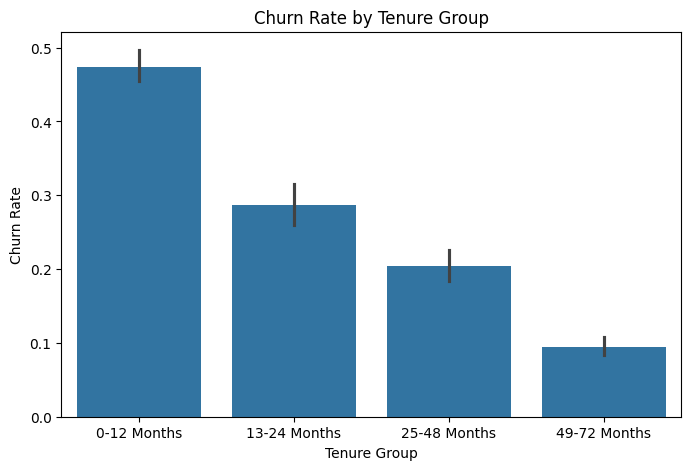

In [45]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df_clean,
    x="TenureGroup",
    y=df_clean["Churn"].eq("Yes").astype(int)
)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate")

plt.show()

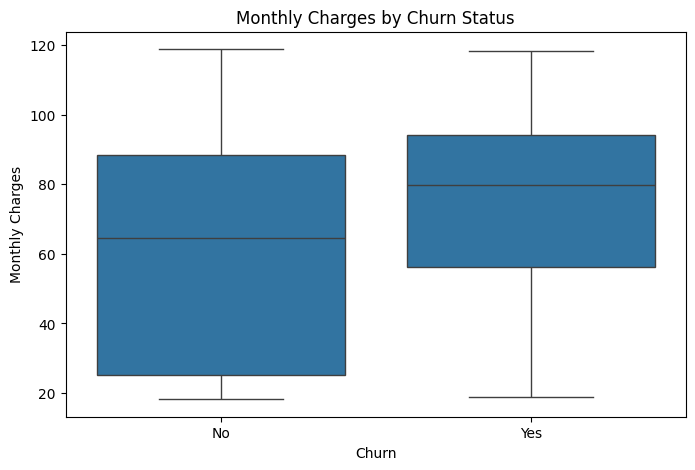

In [46]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_clean,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

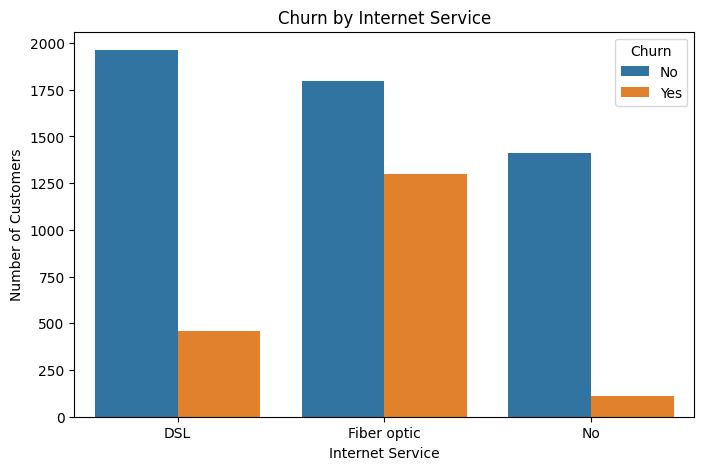

In [47]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="InternetService",
    hue="Churn"
)

plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

In [49]:
internet_churn = pd.crosstab(
    df_clean["InternetService"],
    df_clean["Churn"],
    normalize="index"
) * 100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


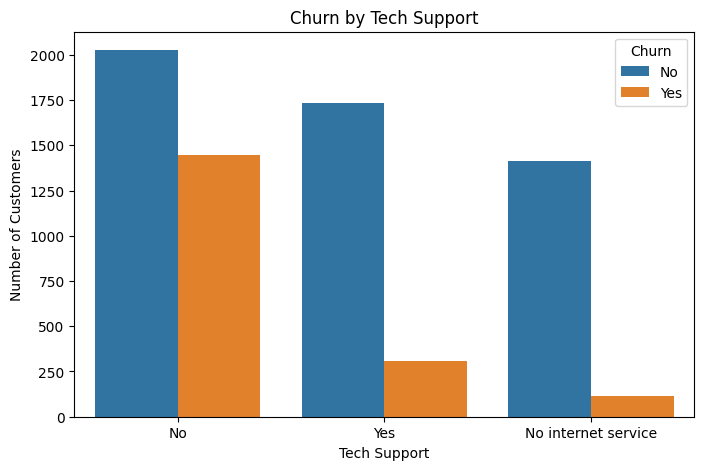

In [51]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_clean,
    x="TechSupport",
    hue="Churn"
)

plt.title("Churn by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Number of Customers")

plt.show()

In [52]:
model_df = df_clean.copy()

In [53]:
model_df = model_df.drop(columns=["customerID"])

In [54]:
model_df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-12 Months
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25-48 Months
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-12 Months
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,25-48 Months
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-12 Months


In [55]:
model_df = model_df.drop(columns=["TenureGroup"])

In [56]:
X = model_df.drop(columns=["Churn"])
y = model_df["Churn"]

In [57]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 19)
y shape: (7043,)


In [58]:
y = y.map({"No": 0, "Yes": 1})

In [59]:
y.value_counts()

,count
Churn,
0,5174
1,1869


In [60]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical Features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [61]:
StandardScaler()

StandardScaler()

In [62]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)

In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [64]:
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5634, 19)
Testing data: (1409, 19)


In [65]:
stratify=y

In [66]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training target distribution:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Testing target distribution:
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [67]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000
        ))
    ]
)

In [68]:
logistic_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [69]:
y_pred = logistic_pipeline.predict(X_test)

In [70]:
y_probability = logistic_pipeline.predict_proba(X_test)[:, 1]

In [71]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probability)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

Accuracy : 0.807
Precision: 0.6604
Recall   : 0.5615
F1 Score : 0.6069
ROC-AUC  : 0.8422


In [72]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [73]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[927 108]
 [164 210]]


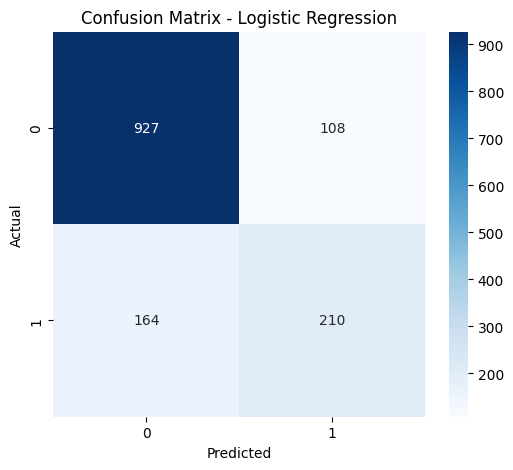

In [74]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [75]:
decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeClassifier(
            random_state=42
        ))
    ]
)

print("Decision Tree pipeline created.")

Decision Tree pipeline created.


In [76]:
decision_tree_pipeline.fit(X_train, y_train)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


In [77]:
dt_pred = decision_tree_pipeline.predict(X_test)

dt_probability = decision_tree_pipeline.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [78]:
dt_accuracy = accuracy_score(y_test, dt_pred)
dt_precision = precision_score(y_test, dt_pred)
dt_recall = recall_score(y_test, dt_pred)
dt_f1 = f1_score(y_test, dt_pred)
dt_roc_auc = roc_auc_score(y_test, dt_probability)

print("Decision Tree Performance")
print("-------------------------")
print("Accuracy :", round(dt_accuracy, 4))
print("Precision:", round(dt_precision, 4))
print("Recall   :", round(dt_recall, 4))
print("F1 Score :", round(dt_f1, 4))
print("ROC-AUC  :", round(dt_roc_auc, 4))

Decision Tree Performance
-------------------------
Accuracy : 0.7253
Precision: 0.4825
Recall   : 0.4786
F1 Score : 0.4805
ROC-AUC  : 0.646


In [79]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.81      0.81      0.81      1035
           1       0.48      0.48      0.48       374

    accuracy                           0.73      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.72      0.73      0.72      1409



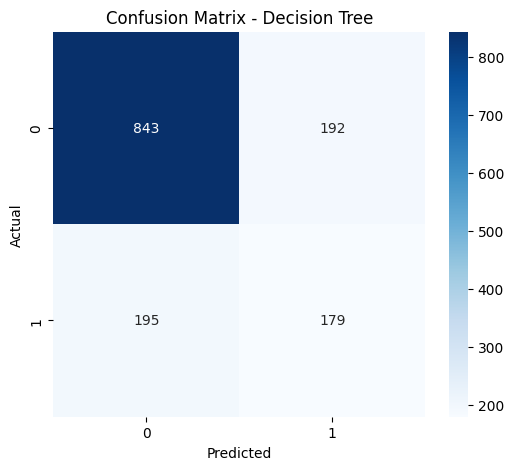

In [80]:
dt_cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    dt_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [81]:
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ))
    ]
)

print("Random Forest pipeline created.")

Random Forest pipeline created.


In [82]:
random_forest_pipeline.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [83]:
rf_pred = random_forest_pipeline.predict(X_test)

rf_probability = random_forest_pipeline.predict_proba(X_test)[:, 1]

print("Random Forest predictions generated successfully.")

Random Forest predictions generated successfully.


In [84]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_probability)

print("Random Forest Performance")
print("------------------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_roc_auc, 4))

Random Forest Performance
------------------------
Accuracy : 0.7899
Precision: 0.6291
Recall   : 0.508
F1 Score : 0.5621
ROC-AUC  : 0.8259


In [85]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.63      0.51      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [86]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy,
        rf_accuracy
    ],
    "Precision": [
        precision,
        dt_precision,
        rf_precision
    ],
    "Recall": [
        recall,
        dt_recall,
        rf_recall
    ],
    "F1 Score": [
        f1,
        dt_f1,
        rf_f1
    ],
    "ROC-AUC": [
        roc_auc,
        dt_roc_auc,
        rf_roc_auc
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.806955,0.660377,0.561497,0.606936,0.842171
1,Decision Tree,0.725337,0.482480,0.478610,0.480537,0.646047
2,Random Forest,0.789922,0.629139,0.508021,0.562130,0.825907


In [87]:
results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8070,0.6604,0.5615,0.6069,0.8422
1,Decision Tree,0.7253,0.4825,0.4786,0.4805,0.6460
2,Random Forest,0.7899,0.6291,0.5080,0.5621,0.8259


In [88]:
class_weight="balanced"

In [89]:
#this is balanced logistic regression
balanced_logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced"
        ))
    ]
)

balanced_logistic_pipeline.fit(X_train, y_train)

balanced_lr_pred = balanced_logistic_pipeline.predict(X_test)
balanced_lr_prob = balanced_logistic_pipeline.predict_proba(X_test)[:, 1]

In [90]:
balanced_lr_accuracy = accuracy_score(y_test, balanced_lr_pred)
balanced_lr_precision = precision_score(y_test, balanced_lr_pred)
balanced_lr_recall = recall_score(y_test, balanced_lr_pred)
balanced_lr_f1 = f1_score(y_test, balanced_lr_pred)
balanced_lr_auc = roc_auc_score(y_test, balanced_lr_prob)

print("Balanced Logistic Regression")
print("----------------------------")
print("Accuracy :", round(balanced_lr_accuracy, 4))
print("Precision:", round(balanced_lr_precision, 4))
print("Recall   :", round(balanced_lr_recall, 4))
print("F1 Score :", round(balanced_lr_f1, 4))
print("ROC-AUC  :", round(balanced_lr_auc, 4))

Balanced Logistic Regression
----------------------------
Accuracy : 0.7388
Precision: 0.5052
Recall   : 0.7834
F1 Score : 0.6143
ROC-AUC  : 0.8417


In [91]:
#this is balanced random forest
balanced_rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

balanced_rf_pipeline.fit(X_train, y_train)

balanced_rf_pred = balanced_rf_pipeline.predict(X_test)
balanced_rf_prob = balanced_rf_pipeline.predict_proba(X_test)[:, 1]

In [92]:
balanced_rf_accuracy = accuracy_score(y_test, balanced_rf_pred)
balanced_rf_precision = precision_score(y_test, balanced_rf_pred)
balanced_rf_recall = recall_score(y_test, balanced_rf_pred)
balanced_rf_f1 = f1_score(y_test, balanced_rf_pred)
balanced_rf_auc = roc_auc_score(y_test, balanced_rf_prob)

print("Balanced Random Forest")
print("----------------------")
print("Accuracy :", round(balanced_rf_accuracy, 4))
print("Precision:", round(balanced_rf_precision, 4))
print("Recall   :", round(balanced_rf_recall, 4))
print("F1 Score :", round(balanced_rf_f1, 4))
print("ROC-AUC  :", round(balanced_rf_auc, 4))

Balanced Random Forest
----------------------
Accuracy : 0.7885
Precision: 0.6267
Recall   : 0.5027
F1 Score : 0.5579
ROC-AUC  : 0.8242


In [93]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Balanced Random Forest"
    ],

    "Accuracy": [
        accuracy,
        balanced_lr_accuracy if 'balanced_lr_accuracy' in globals() else np.nan,
        dt_accuracy,
        rf_accuracy,
        balanced_rf_accuracy
    ],

    "Precision": [
        precision,
        balanced_lr_precision if 'balanced_lr_precision' in globals() else np.nan,
        dt_precision,
        rf_precision,
        balanced_rf_precision
    ],

    "Recall": [
        recall,
        balanced_lr_recall if 'balanced_lr_recall' in globals() else np.nan,
        dt_recall,
        rf_recall,
        balanced_rf_recall
    ],

    "F1 Score": [
        f1,
        balanced_lr_f1 if 'balanced_lr_f1' in globals() else np.nan,
        dt_f1,
        rf_f1,
        balanced_rf_f1
    ],

    "ROC-AUC": [
        roc_auc,
        balanced_lr_auc if 'balanced_lr_auc' in globals() else np.nan,
        dt_roc_auc,
        rf_roc_auc,
        balanced_rf_auc
    ]
})

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8070,0.6604,0.5615,0.6069,0.8422
1,Balanced Logistic Regression,0.7388,0.5052,0.7834,0.6143,0.8417
2,Decision Tree,0.7253,0.4825,0.4786,0.4805,0.6460
3,Random Forest,0.7899,0.6291,0.5080,0.5621,0.8259
4,Balanced Random Forest,0.7885,0.6267,0.5027,0.5579,0.8242


In [97]:
probability = 0.65

# 2. Now run your conditional logic
if probability >= 0.5:
    status = "Churn"
else:
    status = "No Churn"

print(status)

Churn


In [98]:
def evaluate_threshold(y_true, probabilities, threshold):

    predictions = (probabilities >= threshold).astype(int)

    return {
        "Threshold": threshold,
        "Precision": precision_score(y_true, predictions),
        "Recall": recall_score(y_true, predictions),
        "F1 Score": f1_score(y_true, predictions)
    }

In [99]:
thresholds = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70]

threshold_results = []

for threshold in thresholds:
    result = evaluate_threshold(
        y_test,
        balanced_rf_prob,
        threshold
    )

    threshold_results.append(result)

threshold_df = pd.DataFrame(threshold_results)

threshold_df.round(4)

,Threshold,Precision,Recall,F1 Score
0,0.2,0.4743,0.8396,0.6062
1,0.3,0.5272,0.7246,0.6104
2,0.4,0.5804,0.6176,0.5984
3,0.5,0.6291,0.5080,0.5621
4,0.6,0.6893,0.3797,0.4897
5,0.7,0.7518,0.2834,0.4117


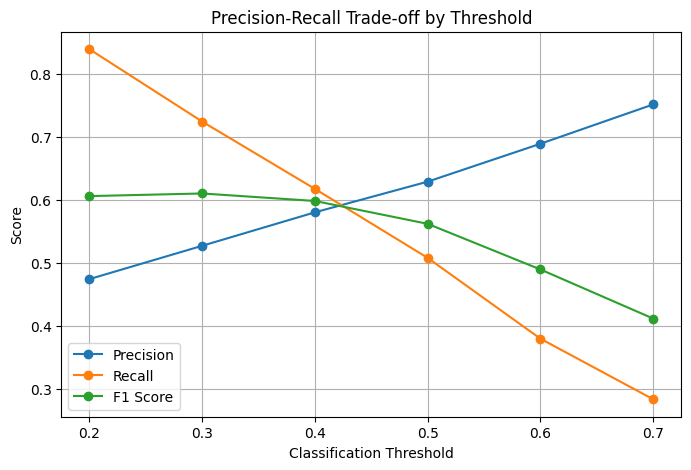

In [100]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Trade-off by Threshold")
plt.legend()
plt.grid(True)

plt.show()

In [101]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1 Score"].idxmax()
]

print("Best threshold based on F1:")
print(best_threshold_row)

Best threshold based on F1:
Threshold    0.300000
Precision    0.527237
Recall       0.724599
F1 Score     0.610360
Name: 1, dtype: float64


In [102]:
best_threshold = best_threshold_row["Threshold"]

print("Selected Threshold:", best_threshold)

Selected Threshold: 0.3


In [103]:
final_pred = (
    balanced_rf_prob >= best_threshold
).astype(int)

In [104]:
final_cm = confusion_matrix(
    y_test,
    final_pred
)

print(final_cm)

[[792 243]
 [103 271]]


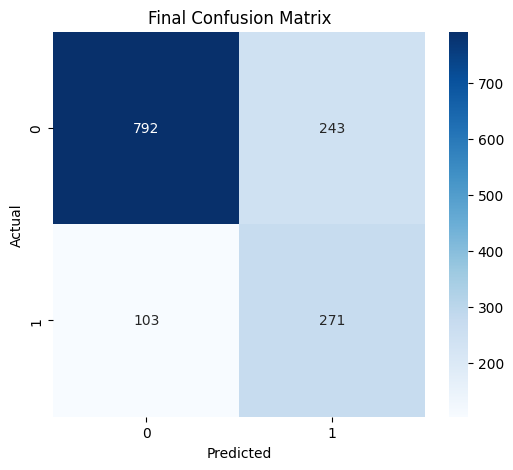

In [105]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Final Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [106]:
final_precision = precision_score(
    y_test,
    final_pred
)

final_recall = recall_score(
    y_test,
    final_pred
)

final_f1 = f1_score(
    y_test,
    final_pred
)

print("Final Precision:", round(final_precision, 4))
print("Final Recall   :", round(final_recall, 4))
print("Final F1 Score  :", round(final_f1, 4))

Final Precision: 0.5272
Final Recall   : 0.7246
Final F1 Score  : 0.6104


In [107]:
feature_names = (
    balanced_rf_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

print("Number of features:", len(feature_names))

Number of features: 30


In [108]:
feature_importance = (
    balanced_rf_pipeline
    .named_steps["model"]
    .feature_importances_
)

In [109]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
3,num__TotalCharges,0.179193
1,num__tenure,0.164111
2,num__MonthlyCharges,0.150375
25,cat__Contract_Two year,0.059210
10,cat__InternetService_Fiber optic,0.041975
28,cat__PaymentMethod_Electronic check,0.036413
24,cat__Contract_One year,0.029916
13,cat__OnlineSecurity_Yes,0.029545
4,cat__gender_Male,0.025899
26,cat__PaperlessBilling_Yes,0.023798


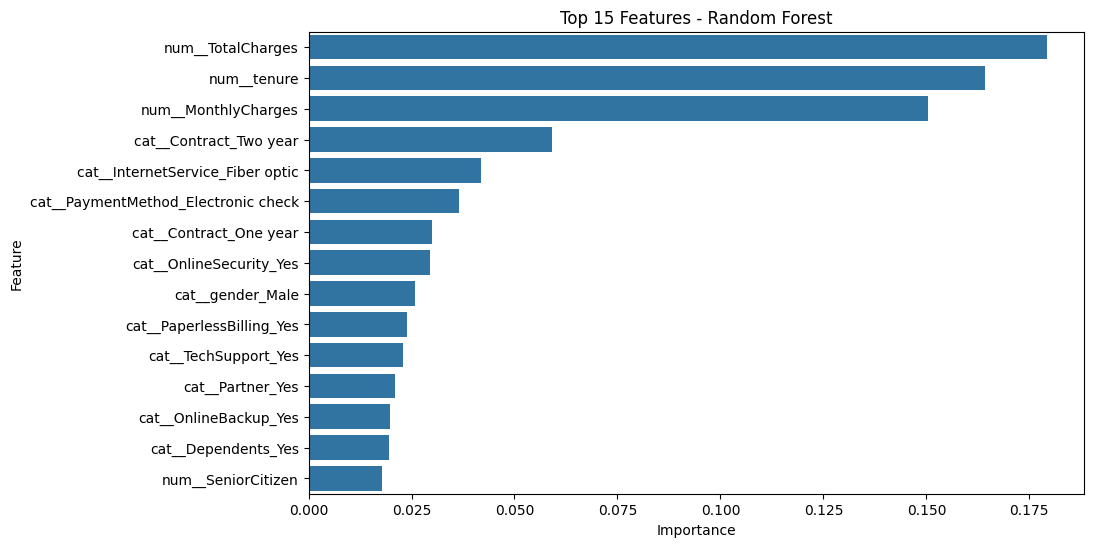

In [110]:
top_features = importance_df.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Features - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [111]:
n_estimators=200

In [112]:
from sklearn.model_selection import GridSearchCV

In [113]:
rf_tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            random_state=42,
            n_jobs=-1
        ))
    ]
)

In [114]:
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__class_weight": [None, "balanced"]
}

In [115]:
"model__n_estimators"

'model__n_estimators'

In [116]:
grid_search = GridSearchCV(
    estimator=rf_tuning_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

In [117]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['SeniorCitizen',
                                                                          'tenure',
                                                                          'MonthlyCharges',
                                                                          'TotalCharges']),
                                                                        ('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         ['gender',
                                                                          'Partner',
                                                                          'Dependents',
                                                                          'PhoneService',
                                                                          'MultipleLines',
                                                                          'InternetService',
                                                                          'OnlineSecurity',
                                                                          'OnlineBackup',
                                                                          '...ection',
                                                                          'TechSupport',
                                                                          'StreamingTV',
                                                                          'StreamingMovies',
                                                                          'Contract',
                                                                          'PaperlessBilling',
                                                                          'PaymentMethod'])])),
                                       ('model',
                                        RandomForestClassifier(n_jobs=-1,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'model__class_weight': [None, 'balanced'],
                         'model__max_depth': [None, 10, 20],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='f1', verbose=1)

In [118]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'model__class_weight': 'balanced', 'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 200}


In [119]:
print("Best Cross-Validation F1 Score:")
print(round(grid_search.best_score_, 4))

Best Cross-Validation F1 Score:
0.6391


In [120]:
tuned_rf_pred = grid_search.predict(X_test)

tuned_rf_prob = grid_search.predict_proba(X_test)[:, 1]

In [121]:
tuned_accuracy = accuracy_score(
    y_test,
    tuned_rf_pred
)

tuned_precision = precision_score(
    y_test,
    tuned_rf_pred
)

tuned_recall = recall_score(
    y_test,
    tuned_rf_pred
)

tuned_f1 = f1_score(
    y_test,
    tuned_rf_pred
)

tuned_auc = roc_auc_score(
    y_test,
    tuned_rf_prob
)

print("Tuned Random Forest")
print("-------------------")
print("Accuracy :", round(tuned_accuracy, 4))
print("Precision:", round(tuned_precision, 4))
print("Recall   :", round(tuned_recall, 4))
print("F1 Score :", round(tuned_f1, 4))
print("ROC-AUC  :", round(tuned_auc, 4))

Tuned Random Forest
-------------------
Accuracy : 0.7665
Precision: 0.5439
Recall   : 0.746
F1 Score : 0.6291
ROC-AUC  : 0.8405


In [122]:
print(
    classification_report(
        y_test,
        tuned_rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.89      0.77      0.83      1035
           1       0.54      0.75      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



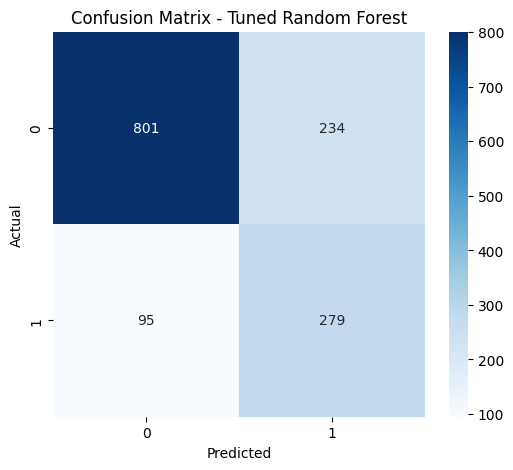

In [123]:
tuned_cm = confusion_matrix(
    y_test,
    tuned_rf_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    tuned_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Tuned Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [124]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Balanced Random Forest",
        "Tuned Random Forest"
    ],

    "Accuracy": [
        accuracy,
        balanced_lr_accuracy,
        dt_accuracy,
        rf_accuracy,
        balanced_rf_accuracy,
        tuned_accuracy
    ],

    "Precision": [
        precision,
        balanced_lr_precision,
        dt_precision,
        rf_precision,
        balanced_rf_precision,
        tuned_precision
    ],

    "Recall": [
        recall,
        balanced_lr_recall,
        dt_recall,
        rf_recall,
        balanced_rf_recall,
        tuned_recall
    ],

    "F1 Score": [
        f1,
        balanced_lr_f1,
        dt_f1,
        rf_f1,
        balanced_rf_f1,
        tuned_f1
    ],

    "ROC-AUC": [
        roc_auc,
        balanced_lr_auc,
        dt_roc_auc,
        rf_roc_auc,
        balanced_rf_auc,
        tuned_auc
    ]
})

final_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8070,0.6604,0.5615,0.6069,0.8422
1,Balanced Logistic Regression,0.7388,0.5052,0.7834,0.6143,0.8417
2,Decision Tree,0.7253,0.4825,0.4786,0.4805,0.6460
3,Random Forest,0.7899,0.6291,0.5080,0.5621,0.8259
4,Balanced Random Forest,0.7885,0.6267,0.5027,0.5579,0.8242
5,Tuned Random Forest,0.7665,0.5439,0.7460,0.6291,0.8405


In [125]:
sql_df = df_clean.copy()

print(sql_df.shape)
sql_df.head()

(7043, 22)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-12 Months
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,25-48 Months
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-12 Months
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,25-48 Months
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-12 Months


In [126]:
sql_df.to_csv(
    "customer_churn_cleaned_data_draft1.csv",
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [127]:
#i am going to do the business analysis here by using the sql
import sqlite3

conn = sqlite3.connect("customer_churn.db")

sql_df.to_sql(
    "customers",
    conn,
    if_exists="replace",
    index=False
)

print("Customers table created successfully.")

Customers table created successfully.


In [128]:
query = """
SELECT COUNT(*) AS total_customers
FROM customers;
"""

pd.read_sql_query(query, conn)

,total_customers
0,7043


In [129]:
query = """
SELECT COUNT(*) AS churned_customers
FROM customers
WHERE Churn = 'Yes';
"""

pd.read_sql_query(query, conn)

,churned_customers
0,1869


In [130]:
query = """
SELECT
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate
FROM customers;
"""

pd.read_sql_query(query, conn)

,total_customers,churned_customers,churn_rate
0,7043,1869,26.54


In [131]:
query = """
SELECT
    Contract,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY Contract
ORDER BY churn_rate DESC;
"""

contract_sql = pd.read_sql_query(query, conn)

contract_sql

,Contract,total_customers,churned_customers,churn_rate
0,Month-to-month,3875,1655,42.71
1,One year,1473,166,11.27
2,Two year,1695,48,2.83


In [132]:
query = """
SELECT
    PaymentMethod,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY PaymentMethod
ORDER BY churn_rate DESC;
"""

payment_sql = pd.read_sql_query(query, conn)

payment_sql

,PaymentMethod,total_customers,churned_customers,churn_rate
0,Electronic check,2365,1071,45.29
1,Mailed check,1612,308,19.11
2,Bank transfer (automatic),1544,258,16.71
3,Credit card (automatic),1522,232,15.24


In [133]:
query = """
SELECT
    InternetService,
    COUNT(*) AS total_customers,
    SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END) AS churned_customers,
    ROUND(
        100.0 * SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate
FROM customers
GROUP BY InternetService
ORDER BY churn_rate DESC;
"""

internet_sql = pd.read_sql_query(query, conn)

internet_sql

,InternetService,total_customers,churned_customers,churn_rate
0,Fiber optic,3096,1297,41.89
1,DSL,2421,459,18.96
2,No,1526,113,7.40


In [134]:
query = """
SELECT
    CASE
        WHEN tenure <= 12 THEN '0-12 Months'
        WHEN tenure <= 24 THEN '13-24 Months'
        WHEN tenure <= 48 THEN '25-48 Months'
        ELSE '49-72 Months'
    END AS tenure_group,

    COUNT(*) AS total_customers,

    SUM(
        CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END
    ) AS churned_customers,

    ROUND(
        100.0 *
        SUM(CASE WHEN Churn = 'Yes' THEN 1 ELSE 0 END)
        / COUNT(*),
        2
    ) AS churn_rate

FROM customers

GROUP BY tenure_group

ORDER BY churn_rate DESC;
"""

tenure_sql = pd.read_sql_query(query, conn)

tenure_sql

,tenure_group,total_customers,churned_customers,churn_rate
0,0-12 Months,2186,1037,47.44
1,13-24 Months,1024,294,28.71
2,25-48 Months,1594,325,20.39
3,49-72 Months,2239,213,9.51


In [135]:
query = """
SELECT
    customerID,
    tenure,
    Contract,
    MonthlyCharges,
    TotalCharges,
    Churn
FROM customers
WHERE MonthlyCharges >= 80
ORDER BY MonthlyCharges DESC
LIMIT 20;
"""

high_charge_customers = pd.read_sql_query(
    query,
    conn
)

high_charge_customers

,customerID,tenure,Contract,MonthlyCharges,TotalCharges,Churn
0,7569-NMZYQ,72,Two year,118.75,8672.45,No
1,8984-HPEMB,71,Two year,118.65,8477.60,No
2,5989-AXPUC,68,Two year,118.60,7990.05,No
3,5734-EJKXG,61,One year,118.60,7365.70,No
4,8199-ZLLSA,67,One year,118.35,7804.15,Yes
5,9924-JPRMC,72,Two year,118.20,8547.15,No
6,2889-FPWRM,72,One year,117.80,8684.80,Yes
7,3810-DVDQQ,72,Two year,117.60,8308.90,No
8,9739-JLPQJ,72,Two year,117.50,8670.10,No
9,2302-ANTDP,48,Month-to-month,117.45,5438.90,Yes


In [136]:
query = """
SELECT
    customerID,
    tenure,
    Contract,
    InternetService,
    MonthlyCharges,
    TotalCharges,
    Churn
FROM customers

WHERE MonthlyCharges >= 70
AND tenure <= 12
AND Contract = 'Month-to-month'

ORDER BY MonthlyCharges DESC;
"""

high_risk_segment = pd.read_sql_query(
    query,
    conn
)

high_risk_segment.head(20)

,customerID,tenure,Contract,InternetService,MonthlyCharges,TotalCharges,Churn
0,1583-IHQZE,12,Month-to-month,Fiber optic,112.95,1384.75,Yes
1,3292-PBZEJ,11,Month-to-month,Fiber optic,111.40,1183.05,No
2,9851-KIELU,10,Month-to-month,Fiber optic,110.10,1043.30,Yes
3,3992-YWPKO,6,Month-to-month,Fiber optic,109.90,669.45,Yes
4,5760-IFJOZ,3,Month-to-month,Fiber optic,107.95,313.60,No
5,2081-VEYEH,3,Month-to-month,Fiber optic,107.95,318.60,No
6,2027-FECZV,12,Month-to-month,Fiber optic,106.70,1253.90,Yes
7,1400-MMYXY,3,Month-to-month,Fiber optic,105.90,334.65,Yes
8,3389-YGYAI,8,Month-to-month,Fiber optic,105.50,829.55,Yes
9,5052-PNLOS,3,Month-to-month,Fiber optic,105.35,323.25,Yes


In [137]:
segment_df = df_clean.copy()

In [138]:
segment_df["TenureSegment"] = pd.cut(
    segment_df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=[
        "New Customer",
        "Early Customer",
        "Established Customer",
        "Long-Term Customer"
    ]
)

In [139]:
segment_df["ChargeSegment"] = pd.qcut(
    segment_df["MonthlyCharges"],
    q=3,
    labels=[
        "Low Charge",
        "Medium Charge",
        "High Charge"
    ]
)

In [140]:
segment_analysis = pd.crosstab(
    [
        segment_df["TenureSegment"],
        segment_df["ChargeSegment"]
    ],
    segment_df["Churn"],
    normalize="index"
) * 100

segment_analysis.round(2)

Churn                                  No    Yes
TenureSegment        ChargeSegment              
New Customer         Low Charge     69.02  30.98
                     Medium Charge  45.93  54.07
                     High Charge    26.26  73.74
Early Customer       Low Charge     89.47  10.53
                     Medium Charge  71.54  28.46
                     High Charge    48.64  51.36
Established Customer Low Charge     94.51   5.49
                     Medium Charge  82.15  17.85
                     High Charge    64.72  35.28
Long-Term Customer   Low Charge     97.45   2.55
                     Medium Charge  94.45   5.55
                     High Charge    84.84  15.16

In [141]:
customer_probabilities = grid_search.predict_proba(X)[:, 1]

In [142]:
customer_risk = df_clean.copy()

customer_risk["ChurnProbability"] = customer_probabilities

In [143]:
customer_risk["RiskCategory"] = pd.cut(
    customer_risk["ChurnProbability"],
    bins=[-0.01, 0.30, 0.60, 1.00],
    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ]
)

In [144]:
customer_risk[
    [
        "customerID",
        "tenure",
        "Contract",
        "MonthlyCharges",
        "ChurnProbability",
        "RiskCategory"
    ]
].head(20)

,customerID,tenure,Contract,MonthlyCharges,ChurnProbability,RiskCategory
0,7590-VHVEG,1,Month-to-month,29.85,0.673329,High Risk
1,5575-GNVDE,34,One year,56.95,0.082531,Low Risk
2,3668-QPYBK,2,Month-to-month,53.85,0.705710,High Risk
3,7795-CFOCW,45,One year,42.30,0.063206,Low Risk
4,9237-HQITU,2,Month-to-month,70.70,0.840438,High Risk
5,9305-CDSKC,8,Month-to-month,99.65,0.909092,High Risk
6,1452-KIOVK,22,Month-to-month,89.10,0.619362,High Risk
7,6713-OKOMC,10,Month-to-month,29.75,0.331105,Medium Risk
8,7892-POOKP,28,Month-to-month,104.80,0.755597,High Risk
9,6388-TABGU,62,One year,56.15,0.086344,Low Risk


In [145]:
high_risk_customers = customer_risk[
    customer_risk["RiskCategory"] == "High Risk"
].sort_values(
    "ChurnProbability",
    ascending=False
)

high_risk_customers[
    [
        "customerID",
        "tenure",
        "Contract",
        "InternetService",
        "MonthlyCharges",
        "ChurnProbability",
        "RiskCategory"
    ]
].head(20)

,customerID,tenure,Contract,InternetService,MonthlyCharges,ChurnProbability,RiskCategory
4800,9300-AGZNL,1,Month-to-month,Fiber optic,94.00,0.946944,High Risk
1976,9497-QCMMS,1,Month-to-month,Fiber optic,93.55,0.946944,High Risk
4585,1069-XAIEM,1,Month-to-month,Fiber optic,85.05,0.941277,High Risk
2208,7216-EWTRS,1,Month-to-month,Fiber optic,100.80,0.939563,High Risk
3209,8149-RSOUN,1,Month-to-month,Fiber optic,93.85,0.939463,High Risk
2577,4910-GMJOT,1,Month-to-month,Fiber optic,94.60,0.939198,High Risk
3380,5178-LMXOP,1,Month-to-month,Fiber optic,95.10,0.938269,High Risk
983,8603-IJWDN,1,Month-to-month,Fiber optic,86.60,0.937536,High Risk
6623,9248-OJYKK,1,Month-to-month,Fiber optic,76.45,0.936846,High Risk
6866,0295-PPHDO,1,Month-to-month,Fiber optic,95.45,0.936280,High Risk


In [146]:
customer_risk.to_csv(
    "customer_churn_risk_predictions_risk.csv",
    index=False
)

print("Risk prediction file created.")

Risk prediction file created.


In [147]:
final_results.to_csv(
    "model_comparison.csv",
    index=False
)

print("Model comparison file created.")

Model comparison file created.


In [148]:
contract_sql.to_csv(
    "contract_churn_analysis.csv",
    index=False
)

payment_sql.to_csv(
    "payment_method_churn_analysis.csv",
    index=False
)

internet_sql.to_csv(
    "internet_service_churn_analysis.csv",
    index=False
)

tenure_sql.to_csv(
    "tenure_churn_analysis.csv",
    index=False
)

print("SQL analysis files created.")

SQL analysis files created.


In [149]:
powerbi_df = customer_risk.copy()

powerbi_df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TenureGroup,ChurnProbability,RiskCategory
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-12 Months,0.673329,High Risk
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,No,25-48 Months,0.082531,Low Risk
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-12 Months,0.705710,High Risk
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,25-48 Months,0.063206,Low Risk
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-12 Months,0.840438,High Risk


In [150]:
powerbi_df.to_csv(
    "PowerBI_Customer_Churn_Data.csv",
    index=False
)

print("Power BI dataset created successfully.")

Power BI dataset created successfully.


In [151]:
from google.colab import files

files.download(
    "PowerBI_Customer_Churn_Data.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>